In [ ]:
# This code was taken from Francois Chollet (2018). Deep Learning with Python. Manning, Shelter Island (pp287-295).
# I have experimented with different hyperparameters and optimisers

In [ ]:
!pip install tensorflow[and-cuda]

In [2]:
!pip install pandas

In [3]:
import tensorflow as tf; 
print(tf.config.list_physical_devices('GPU'))

2025-12-17 22:58:56.873225: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
from tensorflow import keras
import numpy as np

In [5]:
import os, time
import pandas as pd

### 1. Getting the style and content images

In [6]:
# load images
base_image_path = "images/content/puppy.jpg"
style_reference_image_path = "images/style/col.jpg"
original_width, original_height = keras.utils.load_img(base_image_path).size
img_height = 400
img_width = round(original_width * img_height / original_height)

### 2. Auxiliary functions

In [7]:
# Util function to open, resize,and format pictures into appropriate arrays
def preprocess_image(image_path):
    img = keras.utils.load_img(image_path, target_size=(img_height, img_width))
    img = keras.utils.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = keras.applications.vgg19.preprocess_input(img)
    return img

In [8]:
# Util function to convert a NumPy array into a valid image
def deprocess_image(img):
    # Zero-centering by removing the mean pixel value from ImageNet. 
    # This reverses a transformation done by vgg19.preprocess_input.
    img = img.reshape((img_height, img_width, 3))
    img[:, :, 0] += 103.939
    img[:, :, 1] += 116.779
    img[:, :, 2] += 123.68
    
    #Converts images from 'BGR' to 'RGB'.This is also part of the reversal of vgg19.preprocess_input.
    img = img[:, :, ::-1]
    img = np.clip(img, 0, 255).astype("uint8")
    return img

### 3. Using a pretrained VGG19 model to create a feature extractor

In [9]:
# Build a VGG19 model loaded with pretrained ImageNet weights.
model = keras.applications.vgg19.VGG19(weights="imagenet", include_top=False)

outputs_dict = dict([(layer.name, layer.output) for layer in model.layers])

# Model that returns the activation values for every target layer (as a dict)
feature_extractor = keras.Model(inputs=model.inputs, outputs=outputs_dict)

I0000 00:00:1766008762.389706   20250 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3586 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [10]:
outputs_dict.keys()

dict_keys(['input_layer', 'block1_conv1', 'block1_conv2', 'block1_pool', 'block2_conv1', 'block2_conv2', 'block2_pool', 'block3_conv1', 'block3_conv2', 'block3_conv3', 'block3_conv4', 'block3_pool', 'block4_conv1', 'block4_conv2', 'block4_conv3', 'block4_conv4', 'block4_pool', 'block5_conv1', 'block5_conv2', 'block5_conv3', 'block5_conv4', 'block5_pool'])

### 4. Content loss

In [11]:
def content_loss(base_img, combination_img):
    return tf.reduce_sum(tf.square(combination_img - base_img))

### 5. Style loss

In [12]:
def gram_matrix(x):
    x = tf.transpose(x, (2, 0, 1))
    features = tf.reshape(x, (tf.shape(x)[0], -1))
    gram = tf.matmul(features, tf.transpose(features))
    return gram

def style_loss(style_img, combination_img):
    S = gram_matrix(style_img)
    C = gram_matrix(combination_img)
    channels = 3
    size = img_height * img_width
    return tf.reduce_sum(tf.square(S - C)) / (4.0 * (channels ** 2) * (size ** 2))

### 6. Total variation loss
To these two loss components, you add a third: the total variation loss, which operates
on the pixels of the generated combination image. It encourages spatial continuity in
the generated image, thus avoiding overly pixelated results. You can interpret it as a
regularization loss.

In [13]:
def total_variation_loss(x):
    a = tf.square(x[:, : img_height - 1, : img_width - 1, :] - x[:, 1:, : img_width - 1, :])
    b = tf.square(x[:, : img_height - 1, : img_width - 1, :] - x[:, : img_height - 1, 1:, :])
    return tf.reduce_sum(tf.pow(a + b, 1.25))

### 7. Defining the final loss that you’ll minimize

The loss that you minimize is a weighted average of these three losses. To compute the
content loss, you use only one upper layer—the block5_conv2 layer—whereas for the
style loss, you use a list of layers that spans both low-level and high-level layers. You add
the total variation loss at the end.
Depending on the style-reference image and content image you’re using, you’ll
likely want to tune the content_weight coefficient (the contribution of the content
loss to the total loss). A higher content_weight means the target content will be more
recognizable in the generated image.

In [14]:
# layers for style loss
style_layer_names = ["block1_conv1",
            "block2_conv1",
            "block3_conv1",
            "block4_conv1",
            "block5_conv1"]
content_layer_name = "block5_conv2" # the layer for the content loss



In [15]:
def compute_loss(combination_image, base_image, style_reference_image):
    input_tensor = tf.concat([base_image, style_reference_image, combination_image], axis=0)
    features = feature_extractor(input_tensor)
    loss = tf.zeros(shape=())
    layer_features = features[content_layer_name]
    base_image_features = layer_features[0, :, :, :]
    combination_features = layer_features[2, :, :, :]
    loss = loss + content_weight * content_loss(base_image_features, combination_features)
    for layer_name in style_layer_names:
        layer_features = features[layer_name]
        style_reference_features = layer_features[1, :, :, :]
        combination_features = layer_features[2, :, :, :]
        style_loss_value = style_loss(style_reference_features, combination_features)
        loss += (style_weight / len(style_layer_names)) * style_loss_value
        loss += total_variation_weight * total_variation_loss(combination_image)
    return loss

### 8. Setting up the gradient-descent process
Finally, let’s set up the gradient-descent process. In the original Gatys et al. paper, optimization
is performed using the L-BFGS algorithm, but that’s not available in Tensor-
Flow, so we’ll just do mini-batch gradient descent with the SGD optimizer instead. We’ll
leverage an optimizer feature you haven’t seen before: a learning-rate schedule. We’ll
use it to gradually decrease the learning rate from a very high value (100) to a much
smaller final value (about 20). That way, we’ll make fast progress in the early stages of
training and then proceed more cautiously as we get closer to the loss minimum.

In [16]:
#We make the training step fast by compiling it as a tf.function

@tf.function
def compute_loss_and_grads(combination_image, base_image, style_reference_image):
    with tf.GradientTape() as tape:
        loss = compute_loss(combination_image, base_image, style_reference_image)
    grads = tape.gradient(loss, combination_image)
    return loss, grads
    

In [17]:
choice = "adam1"

In [18]:
combinations = "images/generated/"+choice+"/"
loss_history = []
start_time = time.perf_counter()

In [19]:
total_variation_weight = 1e-6
style_weight = 1e-6
content_weight = 2.5e-8 # 1
#content_weight = 2.5e-6 # 2 higher content weight


#optimizer = keras.optimizers.SGD(keras.optimizers.schedules.ExponentialDecay(initial_learning_rate=100.0, decay_steps=100, decay_rate=0.96))
optimizer = keras.optimizers.Adam(learning_rate=5.0, beta_1=0.9, beta_2=0.999, epsilon=1e-7)



Weights:

1)
total_variation_weight = 1e-6  
style_weight = 1e-6  
content_weight = 2.5e-8

2)
total_variation_weight = 1e-6  
style_weight = 1e-6  
content_weight = 2.5e-6 # higher content weight

Optimisers:

1) optimizer = keras.optimizers.SGD(keras.optimizers.schedules.ExponentialDecay(initial_learning_rate=100.0, decay_steps=100, decay_rate=0.96))
2) optimizer = keras.optimizers.Adam(learning_rate=5.0, beta_1=0.9, beta_2=0.999, epsilon=1e-7)



In [20]:
base_image = preprocess_image(base_image_path)
style_reference_image = preprocess_image(style_reference_image_path)
combination_image = tf.Variable(preprocess_image(base_image_path))

iterations = 3000
for i in range(1, iterations + 1):
    loss, grads = compute_loss_and_grads(combination_image, base_image, style_reference_image)
    optimizer.apply_gradients([(grads, combination_image)]) # Update the combination image in a direction that reduces the style transfer loss

    loss_history.append(float(loss.numpy() if hasattr(loss, "numpy") else loss))

    if i % 1000 == 0:
        print(f"Iteration {i}: loss={loss:.2f}")
        img = deprocess_image(combination_image.numpy())
        fname = f"{choice}_at_iteration_{i}.png"
        keras.utils.save_img(combinations+fname, img) # Save the combination image at regular intervals
        
end_time = time.perf_counter()
total_time = end_time - start_time

print(f"\nTotal time for {iterations} iterations: {total_time:.2f} seconds")

df = pd.DataFrame({
    "iteration": range(1, iterations + 1),
    "loss": loss_history
})



2025-12-17 22:59:24.723821: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


Iteration 1000: loss=7642.46
Iteration 2000: loss=7063.15
Iteration 3000: loss=6761.78

Total time for 3000 iterations: 583.34 seconds


In [21]:
loss_file_name = f"statistics/loss_per_iteration_{choice}_{total_time}.csv"
df.to_csv(loss_file_name, index=False)



In [33]:
from PIL import Image

def show_content_and_style_same_size(content_path, style_path, figsize=(6, 3)):
    # Load images
    content_img = Image.open(content_path).convert("RGB")
    style_img = Image.open(style_path).convert("RGB")

    # Resize style image to match content image size
    style_img = style_img.resize(content_img.size, Image.BICUBIC)

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    axes[0].imshow(content_img)
    axes[0].set_title("Content Image", fontsize=10)
    axes[0].axis("off")

    axes[1].imshow(style_img)
    axes[1].set_title("Style Image", fontsize=10)
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


# Evalutation

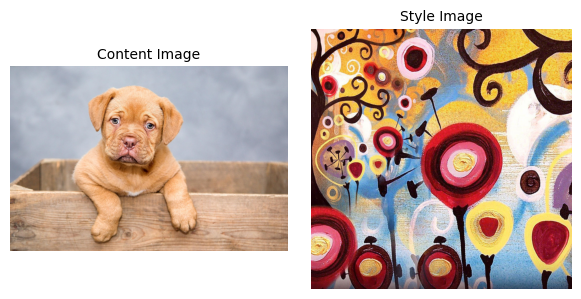

In [34]:
show_content_and_style(
    content_path=base_image_path,
    style_path=style_reference_image_path
)

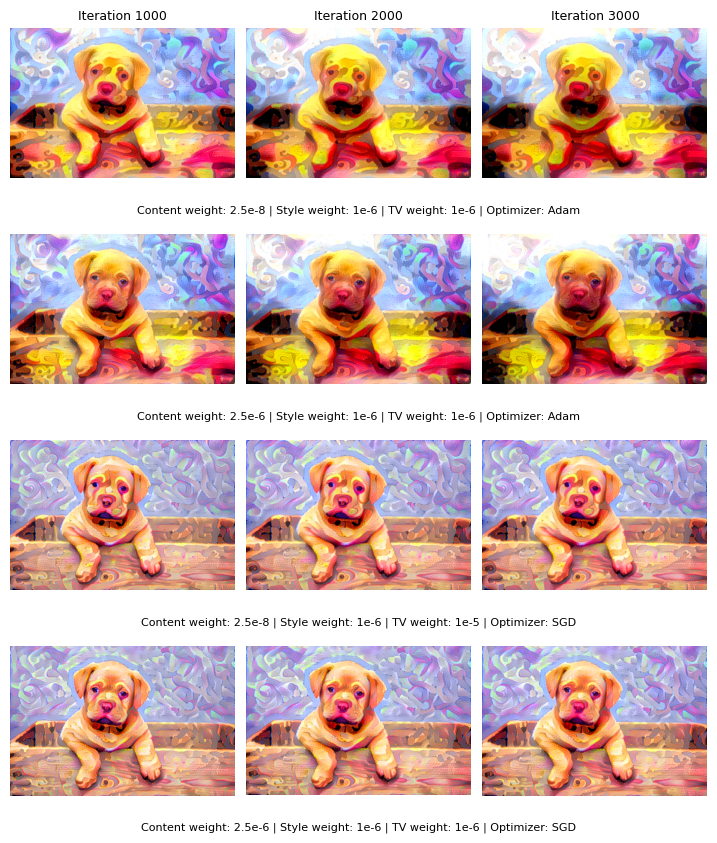

In [30]:
import matplotlib.pyplot as plt

path = "images/generated/"
image_paths = [
    [path+"adam1/adam1_at_iteration_1000.png", path+"adam1/adam1_at_iteration_2000.png", path+"adam1/adam1_at_iteration_3000.png"],
    [path+"adam2/adam2_at_iteration_1000.png", path+"adam2/adam2_at_iteration_2000.png", path+"adam2/adam2_at_iteration_3000.png"],
    [path+"sgd1/sgd1_at_iteration_1000.png",  path+"sgd1/sgd1_at_iteration_2000.png",  path+"sgd1/sgd1_at_iteration_3000.png"],
    [path+"sgd2/sgd2_at_iteration_1000.png",  path+"sgd2/sgd2_at_iteration_2000.png",  path+"sgd2/sgd2_at_iteration_3000.png"],
]

row_labels = [
    "Content weight: 2.5e-8 | Style weight: 1e-6 | TV weight: 1e-6 | Optimizer: Adam",
    "Content weight: 2.5e-6 | Style weight: 1e-6 | TV weight: 1e-6 | Optimizer: Adam",
    "Content weight: 2.5e-8 | Style weight: 1e-6 | TV weight: 1e-5 | Optimizer: SGD",
    "Content weight: 2.5e-6 | Style weight: 1e-6 | TV weight: 1e-6 | Optimizer: SGD",
]

col_labels = ["Iteration 1000", "Iteration 2000", "Iteration 3000"]

# --- Load images ---
images = [[plt.imread(p) for p in row] for row in image_paths]

# --- Plot ---
fig, axes = plt.subplots(4, 3, figsize=(9,10))

for r in range(4):
    for c in range(3):
        ax = axes[r, c]
        ax.imshow(images[r][c])
        ax.axis("off")

        # Column titles (top row only)
        if r == 0:
            ax.set_title(col_labels[c], fontsize=9, pad=6)

    # ---- Row label under the MIDDLE image ----
    mid_ax = axes[r, 1]  # middle column
    mid_ax.text(
        0.5, -0.18,               # centered under image
        row_labels[r],
        ha="center",
        va="top",
        fontsize=8,
        transform=mid_ax.transAxes,
        wrap=True
    )

# Spacing so labels fit
plt.subplots_adjust(wspace=0.05, hspace=0.35)

plt.show()


In [35]:
import pandas as pd

In [40]:
def plot_two_loss_comparisons(
    left_csvs,
    left_labels,
    right_csvs,
    right_labels,
    iteration_col="iteration",
    loss_col="loss",
    figsize=(10, 4)
):


    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # ---- Left plot ----
    for csv_file, label in zip(left_csvs, left_labels):
        df = pd.read_csv(csv_file)
        axes[0].plot(df[iteration_col], df[loss_col], label=label)

    axes[0].set_title("Content weight: 2.5e-8", fontsize=11)
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel("Total Loss")
    axes[0].legend()
    axes[0].grid(True)

    # ---- Right plot ----
    for csv_file, label in zip(right_csvs, right_labels):
        df = pd.read_csv(csv_file)
        axes[1].plot(df[iteration_col], df[loss_col], label=label)

    axes[1].set_title("Content weight: 2.5e-6", fontsize=11)
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Total Loss")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


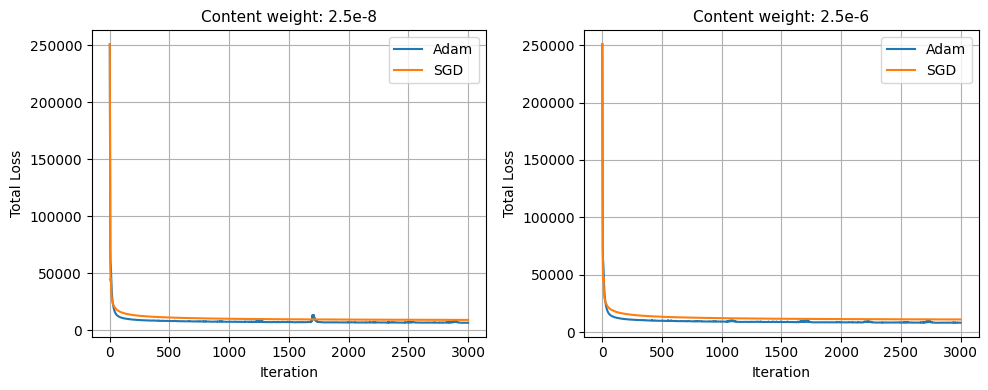

In [41]:
# Left graph (e.g. Adam configs)
left_csvs = [
    "statistics/loss_per_iteration_adam1_583.csv",
    "statistics/loss_per_iteration_sgd1_579.csv"
]
left_labels = [
    "Adam",
    "SGD"
]

# Right graph (e.g. SGD configs)
right_csvs = [
    "statistics/loss_per_iteration_adam2_582.csv",
    "statistics/loss_per_iteration_sgd2_581.csv"
]
right_labels = [
    "Adam",
    "SGD"
]

plot_two_loss_comparisons(
    left_csvs, left_labels,
    right_csvs, right_labels
)
